# Technical Note P5B: NumPy Fields and Grids: FDM Discrete Operators

**Wook Kang · Revised English edition · Version 1.0.0 · 3 October 2026**

This note connects a mathematical task to a numerical object, an implementation, and evidence about the result. It is an instructional computational document. Demonstration parameters are illustrative unless explicitly stated otherwise.

Run from a fresh kernel in cell order. See [the series README](../README.md) for setup and [editorial and verification notes](../docs/EDITORIAL_NOTES.md) for scope and limitations. The English prose has been reorganized and expanded from the supplied Korean notebook; this is an adapted edition rather than a line-by-line translation.

**Reading question:** What is given, what is unknown, what operation relates them, and what independent check can assess the output?

## Core mathematical structure

$$
\boxed{
u(x,y,z)
\rightarrow
U_{ijk}
\rightarrow
\texttt{U[i,j,k]}
}
$$

$$
\boxed{
\text{continuous field}
\rightarrow
\text{grid}
\rightarrow
\text{discrete field}
\rightarrow
\nabla u
\rightarrow
\mathbf q
\rightarrow
\nabla\cdot\mathbf q
}
$$

In [1]:
# Reproducible display and scale-aware comparison.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
def scaled_allclose(a, b, rtol=1e-12, atol=None, **kwargs):
    """Compare numerical examples using an absolute tolerance scaled to b."""
    a, b = np.asarray(a), np.asarray(b)
    scale = float(np.max(np.abs(b))) if b.size else 0.0
    if atol is None:
        atol = 1e-14 * max(scale, np.finfo(float).tiny)
    return np.allclose(a, b, rtol=rtol, atol=atol, **kwargs)


## 1. Grids and fields

A grid records where quantities live; a field records their values. Distinguish nodes, cell centres, and faces before computing differences or boundary conditions.

$$
u_i=u(x_i)
$$

```python
x.shape == (Nx,)
U.shape == (Nx,)
```

$$
\boxed{
\text{coordinate}
\neq
\text{field value}
}
$$

$$
\Delta x=\frac{L}{N-1}
$$

$$
\Delta x=\frac{L}{N},
\qquad
x_i=\left(i+\frac12\right)\Delta x
$$

$$
\boxed{
\text{same shape}
\neq
\text{same location meaning}
}
$$

In [2]:
import numpy as np

L = 1.0
N = 5

x_node = np.linspace(0.0, L, N)
dx_cell = L/N
x_cell = (np.arange(N) + 0.5)*dx_cell
x_face = np.linspace(0.0, L, N+1)

print("nodal points :", x_node)
print("cell centers :", x_cell)
print("cell faces   :", x_face)
print("n cells / faces =", len(x_cell), len(x_face))

nodal points : [0.   0.25 0.5  0.75 1.  ]
cell centers : [0.1 0.3 0.5 0.7 0.9]
cell faces   : [0.  0.2 0.4 0.6 0.8 1. ]
n cells / faces = 5 6


## 2. Structured grids

Use coordinate arrays and an explicit axis convention. Meshgrid with ij indexing matches the x-first convention used in most of these examples.

$$
0\le x\le L_x,
\qquad
0\le y\le L_y
$$

```python
X.shape == (Nx,Ny)
Y.shape == (Nx,Ny)
```

$$
X_{ij}=x_i,
\qquad
Y_{ij}=y_j
$$

$$
u(x,y)=f(x,y)
$$

```python
U = f(X,Y)
```

```python
U.shape == (Nx,Ny,Nz)
```

In [3]:
Lx, Ly = 1.0, 0.5
Nx, Ny = 50, 40

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

X, Y = np.meshgrid(x, y, indexing="ij")
U = np.sin(np.pi*X)*np.cos(np.pi*Y)

print("X shape =", X.shape)
print("Y shape =", Y.shape)
print("U shape =", U.shape)
print("min/max =", U.min(), U.max())

X shape = (50, 40)
Y shape = (50, 40)
U shape = (50, 40)
min/max = 0.0 0.9994862162006879


## 3. Scalar, vector, and tensor fields

Separate location axes from component axes. A sampled tensor also needs a basis convention; its array shape alone does not define a physical tensor.

```python
U.shape == (Nx,Ny)
```

$$
\mathbf v(x,y)=
\begin{bmatrix}
v_x\\
v_y
\end{bmatrix}
$$

```python
V.shape == (Nx,Ny,2)
```

```python
T.shape == (Nx,Ny,2,2)
```

$$
\boxed{
\text{spatial axes}
+
\text{component axes}
}
$$

In [4]:
vx = -Y
vy = X
V = np.stack([vx, vy], axis=-1)

T = np.zeros((Nx, Ny, 2, 2))
T[...,0,0] = 2.0
T[...,1,1] = 1.0
T[...,0,1] = 0.2
T[...,1,0] = 0.2

print("V shape =", V.shape)
print("T shape =", T.shape)
print("tensor at one point =")
print(T[0,0])

V shape = (50, 40, 2)
T shape = (50, 40, 2, 2)
tensor at one point =
[[2.  0.2]
 [0.2 1. ]]


## 4. Gradient

The gradient gives directional rates of change of a scalar field. Coordinate spacing supplies the length scale, so a derivative has different units from the sampled value.

$$
\nabla u=
\begin{bmatrix}
\partial u/\partial x\\
\partial u/\partial y
\end{bmatrix}
$$

$$
u=x^2+3y^2
$$

$$
\frac{\partial u}{\partial x}=2x,
\qquad
\frac{\partial u}{\partial y}=6y
$$

In [5]:
x = np.linspace(0, 1, 61)
y = np.linspace(0, 1, 51)
X, Y = np.meshgrid(x, y, indexing="ij")

U = X**2 + 3*Y**2

dUdx, dUdy = np.gradient(U, x, y, edge_order=2)
gradU = np.stack([dUdx, dUdy], axis=-1)

print("gradU shape =", gradU.shape)
print("max err dU/dx =", np.max(np.abs(dUdx - 2*X)))
print("max err dU/dy =", np.max(np.abs(dUdy - 6*Y)))

dx = x[1] - x[0]
dy = y[1] - y[0]

gx = np.full_like(U, np.nan, dtype=float)
gy = np.full_like(U, np.nan, dtype=float)

gx[1:-1,1:-1] = (U[2:,1:-1] - U[:-2,1:-1])/(2*dx)
gy[1:-1,1:-1] = (U[1:-1,2:] - U[1:-1,:-2])/(2*dy)

print("manual interior shape =", gx[1:-1,1:-1].shape)

gradU shape = (61, 51, 2)
max err dU/dx = 5.684341886080802e-14
max err dU/dy = 5.684341886080802e-14
manual interior shape = (59, 49)


## 5. Flux

A constitutive law maps the gradient to flux. Isotropic, spatially varying scalar, and full anisotropic coefficients represent different models.

$$
\mathbf q=-D\nabla u
$$

$$
D=D(x,y)
$$

```python
Dfield[...,None] * gradU
```

$$
q_i=-D_{ij}\frac{\partial u}{\partial x_j}
$$

```python
np.einsum("...ij,...j->...i", Dtensor, gradU)
```

In [6]:
D0 = 2.0
q_iso = -D0*gradU

Dfield = 1.0 + X
q_var = -Dfield[...,None]*gradU

Nx, Ny = U.shape
Dtensor = np.zeros((Nx, Ny, 2, 2))
Dtensor[...,0,0] = 2.0
Dtensor[...,1,1] = 0.5
Dtensor[...,0,1] = 0.2
Dtensor[...,1,0] = 0.2

q_aniso = -np.einsum("...ij,...j->...i", Dtensor, gradU)

print("q_iso shape   =", q_iso.shape)
print("q_var shape   =", q_var.shape)
print("q_aniso shape =", q_aniso.shape)

q_iso shape   = (61, 51, 2)
q_var shape   = (61, 51, 2)
q_aniso shape = (61, 51, 2)


## 6. Divergence and Laplacian

Divergence measures flux imbalance; the Laplacian is divergence of a gradient. For variable coefficients, divergence of D-gradient-u is generally not D times Laplacian-u.

$$
\nabla\cdot\mathbf q=
\frac{\partial q_x}{\partial x}
+
\frac{\partial q_y}{\partial y}
$$

$$
\nabla^2u=
\frac{\partial^2u}{\partial x^2}
+
\frac{\partial^2u}{\partial y^2}
$$

$$
u=x^2+3y^2
$$

$$
\nabla^2u=8
$$

$$
\boxed{
\nabla\cdot(D\nabla u)
\neq
D\nabla^2u
}
$$

In [7]:
qx = q_aniso[...,0]
qy = q_aniso[...,1]

div_q = (
    np.gradient(qx, x, axis=0, edge_order=2)
    +
    np.gradient(qy, y, axis=1, edge_order=2)
)

d2Udx2 = np.gradient(dUdx, x, axis=0, edge_order=2)
d2Udy2 = np.gradient(dUdy, y, axis=1, edge_order=2)
lapU = d2Udx2 + d2Udy2

print("div_q shape =", div_q.shape)
print("mean interior lapU =", np.mean(lapU[2:-2,2:-2]))

div_q shape = (61, 51)
mean interior lapU = 7.999999999999989


## 6.1. Index shifts become slice shifts

A stencil's neighbour offsets translate into aligned slice offsets. State the uniform Cartesian-grid and interior assumptions before using this shortcut.

$$
\boxed{
\text{index shift}
\longleftrightarrow
\text{slice shift}
}
$$

$$
u_{i-1},\quad u_i,\quad u_{i+1}
$$

```python
u[:-2], u[1:-1], u[2:]
```

$$
\frac{u_{i+1}-u_{i-1}}{2\Delta x}
$$

```python
(u[2:] - u[:-2])/(2*dx)
```

$$
\frac{u_{i+1}-2u_i+u_{i-1}}{\Delta x^2}
$$

```python
(u[2:] - 2*u[1:-1] + u[:-2])/dx**2
```

| Mathematical term | NumPy |  
| --- | --- |  
| $u_{i-1}$ | `u[:-2]` |  
| $u_i$ | `u[1:-1]` |  
| $u_{i+1}$ | `u[2:]` |  
| $u_{i+1}-u_i$ | `u[1:] - u[:-1]` |  
| $u_{i+1}-u_{i-1}$ | `u[2:] - u[:-2]` |  
| $u_{i+1}-2u_i+u_{i-1}$ | `u[2:] - 2*u[1:-1] + u[:-2]` |

## 6.2. One-dimensional first derivatives

Forward and backward differences are first order; the centred difference is second order for sufficiently smooth data on a uniform grid. Boundaries require separate formulas.

$$
u_x|_i
\approx
\frac{u_{i+1}-u_i}{\Delta x}
$$

$$
u_x|_i
\approx
\frac{u_{i+1}-u_{i-1}}{2\Delta x}
$$

In [8]:
x = np.linspace(0, 1, 9)
u = x**3
dx = x[1] - x[0]

du_central = np.full_like(u, np.nan)
du_central[1:-1] = (u[2:] - u[:-2])/(2*dx)

du_exact = 3*x**2

print("central =", du_central)
print("exact   =", du_exact)
print("max interior error =",
      np.nanmax(np.abs(du_central - du_exact)))

central = [     nan 0.0625   0.203125 0.4375   0.765625 1.1875   1.703125 2.3125
      nan]
exact   = [0.       0.046875 0.1875   0.421875 0.75     1.171875 1.6875   2.296875
 3.      ]
max interior error = 0.015625


```python
(u[1:] - u[:-1])/dx
```

$$
\boxed{
\text{same array expression}
\neq
\text{same geometric meaning}
}
$$

## 6.3. One-dimensional second derivatives

The three-point formula approximates the second derivative at an interior node. Its sign is the Laplacian sign, opposite to the positive Poisson operator minus-Laplacian.

$$
u_{xx}|_i
\approx
\frac{u_{i+1}-2u_i+u_{i-1}}{\Delta x^2}
+
O(\Delta x^2)
$$

$$
\boxed{
\frac{1}{\Delta x^2}
[\,1,\;-2,\;1\,]
}
$$

In [9]:
x = np.linspace(0, 1, 41)
u = np.sin(np.pi*x)
dx = x[1] - x[0]

lap = np.full_like(u, np.nan)
lap[1:-1] = (
    u[2:] - 2*u[1:-1] + u[:-2]
)/dx**2

lap_exact = -(np.pi**2)*u

print("max interior error =",
      np.nanmax(np.abs(lap - lap_exact)))

max interior error = 0.005072347099021712


## 6.4. Two-dimensional five-point stencil

Add second differences in each coordinate with their own spacing. Axis 0 is x in this example, which differs from the row-first convention in some later catalogue examples.

$$
\nabla^2u=u_{xx}+u_{yy}
$$

$$
(\nabla^2u)_{i,j}
\approx
\frac{u_{i+1,j}-2u_{i,j}+u_{i-1,j}}{\Delta x^2}
+
\frac{u_{i,j+1}-2u_{i,j}+u_{i,j-1}}{\Delta y^2}.
$$

$$
\boxed{
\frac{1}{h^2}
\begin{bmatrix}
 &1&\\
1&-4&1\\
 &1&
\end{bmatrix}
}
$$

In [10]:
Lx, Ly = 1.0, 1.0
Nx, Ny = 51, 61

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing="ij")
U = np.sin(np.pi*X)*np.sin(np.pi*Y)

lap = np.full_like(U, np.nan)

lap[1:-1,1:-1] = (
    (U[2:,1:-1] - 2*U[1:-1,1:-1] + U[:-2,1:-1])/dx**2
    +
    (U[1:-1,2:] - 2*U[1:-1,1:-1] + U[1:-1,:-2])/dy**2
)

lap_exact = -2*np.pi**2*U

print("max interior error =",
      np.nanmax(np.abs(
          lap[1:-1,1:-1] - lap_exact[1:-1,1:-1]
      )))

max interior error = 0.0055011764677104225


```python
U[1:-1, 1:-1]
```

```python
U[2:,  1:-1]   # i+1
U[:-2, 1:-1]   # i-1
```

```python
U[1:-1, 2:]    # j+1
U[1:-1, :-2]   # j-1
```

$$
\boxed{
(i\pm1,j),\;(i,j\pm1)
\longrightarrow
\text{shifted slices}
}
$$

## 6.5. Three-dimensional seven-point stencil

Sum the three directional second differences. NaN marks boundary entries that this interior operator intentionally leaves undefined.

$$
\nabla^2u=u_{xx}+u_{yy}+u_{zz}
$$

$$
(i\pm1,j,k),\quad
(i,j\pm1,k),\quad
(i,j,k\pm1)
$$

In [11]:
Nx, Ny, Nz = 18, 16, 14

x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
z = np.linspace(0, 1, Nz)

dx = x[1]-x[0]
dy = y[1]-y[0]
dz = z[1]-z[0]

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
U = np.sin(np.pi*X)*np.sin(np.pi*Y)*np.sin(np.pi*Z)

lap3 = np.full_like(U, np.nan)

lap3[1:-1,1:-1,1:-1] = (
    (U[2:,1:-1,1:-1] - 2*U[1:-1,1:-1,1:-1] + U[:-2,1:-1,1:-1])/dx**2
    +
    (U[1:-1,2:,1:-1] - 2*U[1:-1,1:-1,1:-1] + U[1:-1,:-2,1:-1])/dy**2
    +
    (U[1:-1,1:-1,2:] - 2*U[1:-1,1:-1,1:-1] + U[1:-1,1:-1,:-2])/dz**2
)

lap3_exact = -3*np.pi**2*U

print("3D field shape =", U.shape)
print("max interior error =",
      np.nanmax(np.abs(
          lap3[1:-1,1:-1,1:-1]
          - lap3_exact[1:-1,1:-1,1:-1]
      )))

3D field shape = (18, 16, 14)
max interior error = 0.11012174051893453


## 6.6. Periodic differences with roll

Roll wraps indices across array endpoints and therefore imposes periodic adjacency. Use a periodic grid without duplicating its endpoint.

```python
lap = (
    np.roll(u, 1)
    - 2*u
    + np.roll(u, -1)
)/dx**2
```

```python
lap = (
    (np.roll(U, 1, axis=0) - 2*U + np.roll(U, -1, axis=0))/dx**2
    +
    (np.roll(U, 1, axis=1) - 2*U + np.roll(U, -1, axis=1))/dy**2
)
```

$$
\boxed{
\texttt{np.roll}
\Rightarrow
\text{periodic topology}
}
$$

In [12]:
N = 80
L = 2*np.pi
x = np.linspace(0, L, N, endpoint=False)
dx = L/N

u = np.sin(3*x)

lap_roll = (
    np.roll(u, 1) - 2*u + np.roll(u, -1)
)/dx**2

lap_exact = -9*np.sin(3*x)

print("periodic np.roll max error =",
      np.max(np.abs(lap_roll - lap_exact)))

periodic np.roll max error = 0.04156041779391195


## 6.7. Variable coefficients and face fluxes

Construct face gradients and face coefficients before taking divergence. A shared face flux preserves cancellation between neighbouring control volumes.

$$
\nabla\cdot(D\nabla u)=D\nabla^2u
$$

$$
\boxed{
\nabla\cdot(D\nabla u)
\neq
D\nabla^2u
}
$$

$$
\boxed{
u_i
\rightarrow
(\nabla u)_{i+1/2}
\rightarrow
D_{i+1/2}
\rightarrow
q_{i+1/2}
\rightarrow
(\nabla\cdot q)_i
}
$$

In [13]:
x = np.linspace(0, 1, 101)
dx = x[1]-x[0]

u = np.sin(np.pi*x)
D = 1.0 + 2.0*x

grad_face = (u[1:] - u[:-1])/dx

D_face = 2*D[:-1]*D[1:] / (D[:-1] + D[1:])

q_face = -D_face*grad_face

div_q = np.full_like(u, np.nan)
div_q[1:-1] = (q_face[1:] - q_face[:-1])/dx

# exact q_x for q = -D u_x
div_q_exact = (
    -2*np.pi*np.cos(np.pi*x)
    + (1+2*x)*np.pi**2*np.sin(np.pi*x)
)

print("max conservative interior error =",
      np.nanmax(np.abs(
          div_q[1:-1] - div_q_exact[1:-1]
      )))

max conservative interior error = 0.0024656115737222706


$$
\boxed{
D_{i+1/2}=
\frac{2D_iD_{i+1}}{D_i+D_{i+1}}
}
$$

## 6.8. Diagonal anisotropic diffusion

Independent directional second differences apply to constant diagonal coefficients in the selected basis. Spatially varying or off-diagonal tensors need a more general conservative discretization.

$$
\mathbf D=
\begin{bmatrix}
D_x&0\\
0&D_y
\end{bmatrix}
$$

$$
\nabla\cdot(\mathbf D\nabla u)=
D_xu_{xx}+D_yu_{yy}.
$$

In [14]:
Nx, Ny = 51, 41
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
dx = x[1]-x[0]
dy = y[1]-y[0]

X, Y = np.meshgrid(x, y, indexing="ij")
U = np.sin(np.pi*X)*np.sin(2*np.pi*Y)

Dx = 2.0
Dy = 0.5

Lu = np.full_like(U, np.nan)
Lu[1:-1,1:-1] = (
    Dx*(U[2:,1:-1] - 2*U[1:-1,1:-1] + U[:-2,1:-1])/dx**2
    +
    Dy*(U[1:-1,2:] - 2*U[1:-1,1:-1] + U[1:-1,:-2])/dy**2
)

Lu_exact = -(Dx*np.pi**2 + Dy*(2*np.pi)**2)*U

print("max anisotropic interior error =",
      np.nanmax(np.abs(
          Lu[1:-1,1:-1] - Lu_exact[1:-1,1:-1]
      )))

max anisotropic interior error = 0.04704683929354303


$$
\mathbf D=
\begin{bmatrix}
D_{xx}&D_{xy}\\
D_{yx}&D_{yy}
\end{bmatrix}
$$

$$
\boxed{
\text{diagonal anisotropy}\neq\text{full rotated anisotropy}
}
$$

## 6.9. Boundary conditions are operators

Dirichlet fixes a boundary value; Neumann specifies a derivative or flux; Robin couples flux and boundary state. Declare the outward normal and distinguish a derivative from a physical flux.

$$
\boxed{
\text{discrete PDE}=
\text{interior operator}
+
\text{boundary operator}
}
$$

$$
u(L)=u_B
$$

```python
u[-1] = uB
```

$$
u_x(L)=g
$$

$$
\frac{u_N-u_{N-1}}{\Delta x}=g
$$

$$
\boxed{
u_N=u_{N-1}+g\Delta x
}
$$

$$
\boxed{
u_N=
\frac{4u_{N-1}-u_{N-2}+2g\Delta x}{3}
}
$$

In [15]:
u = np.array([0.10, 0.14, 0.19, 0.25, 0.0], dtype=float)
dx = 0.1
g = 0.4

u_first = u.copy()
u_first[-1] = u_first[-2] + g*dx

u_second = u.copy()
u_second[-1] = (
    4*u_second[-2] - u_second[-3] + 2*g*dx
)/3

print("Neumann first-order  =", u_first[-1])
print("Neumann second-order =", u_second[-1])

Neumann first-order  = 0.29000000000000004
Neumann second-order = 0.2966666666666667


$$
-D\frac{du}{dx}=
h(u-u_\infty)
$$

$$
-D\frac{u_N-u_{N-1}}{\Delta x}=
h(u_N-u_\infty).
$$

$$
\boxed{
u_N=
\frac{(D/\Delta x)u_{N-1}+hu_\infty}
{D/\Delta x+h}
}
$$

In [16]:
u = np.array([0.30, 0.27, 0.23, 0.19, 0.0], dtype=float)

D = 2.0e-10
h = 1.0e-8
u_inf = 0.10
dx = 0.01

u[-1] = (
    (D/dx)*u[-2] + h*u_inf
) / (
    D/dx + h
)

res_bc = -D*(u[-1]-u[-2])/dx - h*(u[-1]-u_inf)

print("Robin boundary value =", u[-1])
print("Robin residual =", res_bc)

Robin boundary value = 0.15999999999999998
Robin residual = 9.305781891221561e-25


$$
-D\nabla u\cdot\mathbf n=
h(u-u_\infty)
$$

## 6.10. From a stencil to a sparse matrix

Interior coefficients become matrix diagonals after unknown ordering and boundary treatment are fixed. Nonzero prescribed boundary values contribute to the right-hand side.

$$
\mathbf L=
\frac{1}{\Delta x^2}
\begin{bmatrix}
-2&1&&\\
1&-2&1&\\
&\ddots&\ddots&\ddots\\
&&1&-2
\end{bmatrix}.
$$

```python
u[2:] - 2*u[1:-1] + u[:-2]
```

$$
\mathbf L\mathbf u
$$

In [17]:
from scipy.sparse import diags

N = 8
dx = 0.1

L1 = diags(
    [
        np.ones(N-1),
        -2*np.ones(N),
        np.ones(N-1)
    ],
    offsets=[-1, 0, 1],
    format="csr"
) / dx**2

print("L1 shape =", L1.shape)
print("nonzeros =", L1.nnz)
print(L1.toarray())

L1 shape = (8, 8)
nonzeros = 22
[[-200.  100.    0.    0.    0.    0.    0.    0.]
 [ 100. -200.  100.    0.    0.    0.    0.    0.]
 [   0.  100. -200.  100.    0.    0.    0.    0.]
 [   0.    0.  100. -200.  100.    0.    0.    0.]
 [   0.    0.    0.  100. -200.  100.    0.    0.]
 [   0.    0.    0.    0.  100. -200.  100.    0.]
 [   0.    0.    0.    0.    0.  100. -200.  100.]
 [   0.    0.    0.    0.    0.    0.  100. -200.]]


## 6.11. Kronecker sums

For C-order flattening of an x-first array, use Lx-kron-Iy plus Ix-kron-Ly. Check this expression against an explicit field stencil.

```python
U.shape == (Nx, Ny)
```

$$
\boxed{
L_{2D}=
L_x\otimes I_y
+
I_x\otimes L_y
}
$$

In [18]:
from scipy.sparse import diags, eye, kron

Nx, Ny = 5, 4
dx, dy = 0.2, 0.25

Lx = diags(
    [np.ones(Nx-1), -2*np.ones(Nx), np.ones(Nx-1)],
    [-1, 0, 1],
    format="csr"
) / dx**2

Ly = diags(
    [np.ones(Ny-1), -2*np.ones(Ny), np.ones(Ny-1)],
    [-1, 0, 1],
    format="csr"
) / dy**2

Ix = eye(Nx, format="csr")
Iy = eye(Ny, format="csr")

L2 = kron(Lx, Iy) + kron(Ix, Ly)

print("L2 shape =", L2.shape)
print("L2 nnz   =", L2.nnz)

L2 shape = (20, 20)
L2 nnz   = 82


$$
\boxed{
\text{interior sparse operator}
\neq
\text{complete PDE system}
}
$$

## 6.12. Matrix-free evaluation

An operator function evaluates a stencil without building a matrix. Boundary handling remains part of the operator's mathematical definition.

```python
Lu = laplacian_2d(U, dx, dy)
```

In [19]:
def laplacian_2d(U, dx, dy):
    Lu = np.full_like(U, np.nan, dtype=float)
    Lu[1:-1,1:-1] = (
        (U[2:,1:-1] - 2*U[1:-1,1:-1] + U[:-2,1:-1])/dx**2
        +
        (U[1:-1,2:] - 2*U[1:-1,1:-1] + U[1:-1,:-2])/dy**2
    )
    return Lu

x = np.linspace(0, 1, 31)
y = np.linspace(0, 1, 41)
dx = x[1]-x[0]
dy = y[1]-y[0]

X, Y = np.meshgrid(x, y, indexing="ij")
U = np.sin(np.pi*X)*np.sin(np.pi*Y)

Lu = laplacian_2d(U, dx, dy)

print("Lu shape =", Lu.shape)
print("mean finite interior value =", np.nanmean(Lu))

Lu shape = (31, 41)
mean finite interior value = -8.469896212356948


## 6.13. Nonlinear diffusion

Evaluate the coefficient from the current state, transfer it to faces, and take conservative flux differences. This makes the operator nonlinear without changing the field locations.

$$
\frac{\partial u}{\partial t}=
\frac{\partial}{\partial x}
\left[
D(u)\frac{\partial u}{\partial x}
\right]
$$

In [20]:
def harmonic_mean(a, b, eps=1e-30):
    return 2*a*b/(a+b+eps)

def div_D_grad_1d(u, D, dx):
    grad_face = (u[1:] - u[:-1]) / dx
    D_face = harmonic_mean(D[:-1], D[1:])
    flux_like = D_face * grad_face

    out = np.full_like(u, np.nan, dtype=float)
    out[1:-1] = (
        flux_like[1:] - flux_like[:-1]
    ) / dx
    return out

x = np.linspace(0, 1, 101)
dx = x[1]-x[0]

u = 0.15 + 0.05*np.sin(np.pi*x)
D = 1e-10*np.exp(8*(u-0.15))

Lu = div_D_grad_1d(u, D, dx)

print("operator shape =", Lu.shape)
print("finite interior =", np.isfinite(Lu[1:-1]).all())

operator shape = (101,)
finite interior = True


$$
\boxed{
D=D(u)
\rightarrow
D_{face}
\rightarrow
J_{face}
\rightarrow
\nabla\cdot J
}
$$

## 6.14. Verify spatial order

Use a known smooth field on successively refined grids. Observed order estimates apply in the asymptotic regime; one small error is not an order test.

$$
u(x,y)=\sin(\pi x)\sin(\pi y)
$$

$$
\nabla^2u=-2\pi^2u.
$$

$$
\boxed{
E(h)\sim Ch^2
}
$$

In [21]:
def laplacian_error(N):
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)

    dx = x[1]-x[0]
    dy = y[1]-y[0]

    X, Y = np.meshgrid(x, y, indexing="ij")
    U = np.sin(np.pi*X)*np.sin(np.pi*Y)

    Lu = laplacian_2d(U, dx, dy)
    exact = -2*np.pi**2*U

    err = np.nanmax(np.abs(
        Lu[1:-1,1:-1] - exact[1:-1,1:-1]
    ))

    return dx, err

Ns = [21, 41, 81, 161]
results = [laplacian_error(N) for N in Ns]

print(" N      h             max error       order")
prev_h = prev_e = None

for N, (h, e) in zip(Ns, results):
    if prev_h is None:
        order = np.nan
    else:
        order = np.log(prev_e/e)/np.log(prev_h/h)

    print(f"{N:3d}  {h:12.5e}  {e:12.5e}  {order:8.4f}")

    prev_h, prev_e = h, e

 N      h             max error       order
 21   5.00000e-02   4.05538e-02       nan
 41   2.50000e-02   1.01447e-02    1.9991
 81   1.25000e-02   2.53656e-03    1.9998
161   6.25000e-03   6.34166e-04    1.9999


$$
E(h/2)\approx\frac14E(h)
$$

## 6.15. Four representations of derivatives

Gradient inspection, direct slicing, sparse matrices, and matrix-free functions serve different purposes. They should agree only when they implement the same operator and boundary assumptions.

| Purpose | Suggested representation |  
| --- | --- |  
| Quick field inspection | `np.gradient` |  
| Explicit control of stencil meaning | slicing |  
| explicit time stepping | slicing / operator function |  
| implicit linear PDE | sparse matrix |  
| nonlinear $D(u)$ | Flux-form callable or sparse reassembly |  
| JFNK / matrix-free Newton | operator function |  
| periodic structured grid | `np.roll` |  
| irregular / unstructured geometry | Often better handled by FVM or FEM |

## 6.16. Why the connection is easy to miss

Calculus, arrays, and solver interfaces are often taught separately. Writing the index expression beside the slice expression supplies the missing bridge.

$$
\boxed{
u_{i+1,j}
\longleftrightarrow
U[2:,1:-1]
}
$$

## 6.17. P5 and P6 have different roles

P5 explains what a spatial operator means. P6 explains how independent arithmetic can be expressed efficiently without changing that meaning.

$$
\boxed{
\text{P5 = discretization meaning},
\qquad
\text{P6 = vectorized implementation}
}
$$

## 6.18. Scope of these simple stencils

These examples assume structured Cartesian grids and specified field locations. Curved grids, interfaces, tensor cross terms, and irregular boundaries require additional geometric and discretization work.

## 7. Cell-to-face-to-cell operations

Compute a gradient between cell centres, assign a face coefficient, evaluate a face flux, then take flux differences. Boundary face fluxes complete the conservative operator.

$$
\left.\frac{du}{dx}\right|_{i+1/2}
\approx
\frac{u_{i+1}-u_i}{\Delta x}
$$

$$
D_{i+1/2}=
\frac{2D_iD_{i+1}}{D_i+D_{i+1}}
$$

$$
q_{i+1/2}=
-D_{i+1/2}
\frac{u_{i+1}-u_i}{\Delta x}
$$

$$
(\nabla\cdot q)_i
\approx
\frac{q_{i+1/2}-q_{i-1/2}}{\Delta x}
$$

$$
\boxed{
\text{cell state}
\rightarrow
\text{face gradient}
\rightarrow
\text{face flux}
\rightarrow
\text{cell balance}
}
$$

In [22]:
u = np.array([0.30, 0.28, 0.24, 0.20, 0.17])
D = np.array([1.0, 1.2, 1.5, 2.0, 2.5])
dx = 0.01

grad_face = (u[1:] - u[:-1])/dx
D_face = 2*D[:-1]*D[1:] / (D[:-1] + D[1:])
q_face = -D_face*grad_face
div_q_internal = (q_face[1:] - q_face[:-1])/dx

print("cell field shape =", u.shape)
print("face grad shape  =", grad_face.shape)
print("face flux shape  =", q_face.shape)
print("internal div shape =", div_q_internal.shape)

cell field shape = (5,)
face grad shape  = (4,)
face flux shape  = (4,)
internal div shape = (3,)


## 8. Two-dimensional face shapes

Internal x faces have shape (Nx-1,Ny), and internal y faces have shape (Nx,Ny-1). Including boundary faces gives (Nx+1,Ny) and (Nx,Ny+1).

```python
U.shape == (Nx,Ny)
```

```python
U[1:,:] - U[:-1,:]
```

```python
(Nx-1,Ny)
```

```python
U[:,1:] - U[:,:-1]
```

```python
(Nx,Ny-1)
```

In [23]:
Lx, Ly = 1.0, 0.5
Nx, Ny = 6, 4

dx = Lx/Nx
dy = Ly/Ny

xc = (np.arange(Nx)+0.5)*dx
yc = (np.arange(Ny)+0.5)*dy
Xc, Yc = np.meshgrid(xc, yc, indexing="ij")

Uc = Xc**2 + Yc**2

gx_face = (Uc[1:,:] - Uc[:-1,:])/dx
gy_face = (Uc[:,1:] - Uc[:,:-1])/dy

print("cell field =", Uc.shape)
print("x faces    =", gx_face.shape)
print("y faces    =", gy_face.shape)

cell field = (6, 4)
x faces    = (5, 4)
y faces    = (6, 3)


## 9. Boundary masks and material regions

A mask identifies a region and can assign a material coefficient. It does not automatically discretize the boundary or handle a discontinuous coefficient correctly.

$$
x^2+y^2\le R^2
$$

```python
X < 0
X >= 0
```

In [24]:
x = np.linspace(-1, 1, 101)
y = np.linspace(-1, 1, 101)
Xr, Yr = np.meshgrid(x, y, indexing="ij")

mask = Xr**2 + Yr**2 <= 0.6**2

Dreg = np.ones_like(Xr)
Dreg[Xr < 0] = 1.0
Dreg[Xr >= 0] = 0.2

print("active fraction =", np.count_nonzero(mask)/mask.size)
print("left D =", np.unique(Dreg[Xr < 0]))
print("right D =", np.unique(Dreg[Xr >= 0]))

active fraction = 0.2759533379080482
left D = [1.]
right D = [0.2]


## 10. Means, integrals, and samples

A physical mean generally requires volume weights. Cell-centred quadrature and nodal quadrature use different weights; paired indices sample pairs rather than all combinations.

$$
\bar u=\frac1N\sum_i u_i
$$

$$
\bar u=
\frac{\sum_i u_iV_i}{\sum_iV_i}
$$

$$
\int u\,dx
\approx
\sum_i u_i\Delta x
$$

In [25]:
u = np.array([1.0, 2.0, 4.0])
V = np.array([1.0, 2.0, 3.0])

print("simple mean   =", np.mean(u))
print("weighted mean =", np.sum(u*V)/np.sum(V))

L = 1.0
N = 100
dx = L/N
x = (np.arange(N)+0.5)*dx
u = x**2

print("integral numerical =", np.sum(u)*dx)
print("integral exact     =", 1/3)

U = np.arange(30).reshape(5,6)
ii = np.array([0,2,4])
jj = np.array([1,3,5])
print("samples =", U[ii,jj])

simple mean   = 2.3333333333333335
weighted mean = 2.8333333333333335
integral numerical = 0.33332500000000004
integral exact     = 0.3333333333333333
samples = [ 1 15 29]


## 11. Field-to-vector mapping

Use one declared flattening order for fields and global unknowns. Boundary elimination and sparse-matrix assembly must use the same mapping.

$$
U_{ij}
\leftrightarrow
u_I
$$

```python
U.ravel()
uvec.reshape(U.shape)
```

$$
I=iN_y+j
$$

In [26]:
U = np.arange(12).reshape(3,4)
uvec = U.ravel()
Uback = uvec.reshape(U.shape)

print("U shape    =", U.shape)
print("uvec shape =", uvec.shape)
print("same?", np.array_equal(U, Uback))

shape = (3,4)
I = np.ravel_multi_index((2,1), shape)
ij = np.unravel_index(I, shape)

print("I =", I, " -> ij =", ij)

U shape    = (3, 4)
uvec shape = (12,)
same? True
I = 9  -> ij = (np.int64(2), np.int64(1))


## 12. Visualize a field

For x-first storage, transpose for row-column image display when required. Label coordinates and verify orientation with a known asymmetric field.

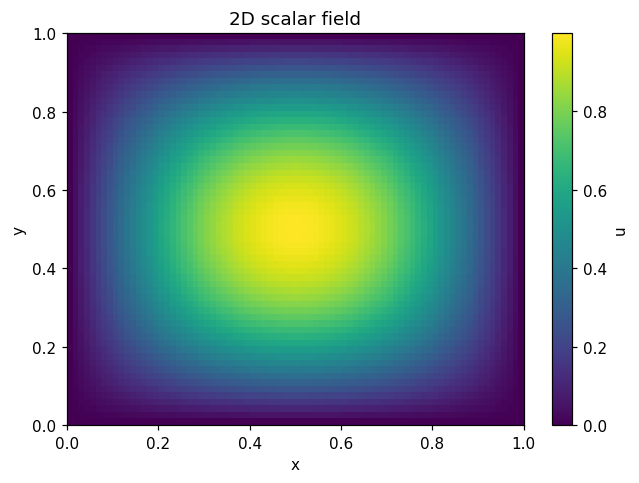

In [27]:
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 80)
y = np.linspace(0, 1, 60)
Xv, Yv = np.meshgrid(x, y, indexing="ij")
Uv = np.sin(np.pi*Xv)*np.sin(np.pi*Yv)

plt.figure(figsize=(6,4.5))
plt.imshow(
    Uv.T,
    origin="lower",
    aspect="auto",
    extent=[x.min(),x.max(),y.min(),y.max()]
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D scalar field")
plt.colorbar(label="u")
plt.tight_layout()
plt.show()

## 13. Gradient and flux are different

A gradient is a geometric derivative; flux also depends on the constitutive coefficient and its basis. Their magnitudes and units should not be conflated.

$$
\nabla u
$$

$$
\mathbf q=-\mathbf D\nabla u
$$

$$
\boxed{
\text{gradient}
\neq
\text{flux}
}
$$

$$
\boxed{
u
\rightarrow
\nabla u
\rightarrow
\mathbf q
\rightarrow
\nabla\cdot\mathbf q
}
$$

```text
U
↓
gradU
↓
q
↓
div_q
↓
state update
```

## 14. What np.gradient establishes

Gradient is useful for inspecting smooth sampled fields. Repeated differentiation does not automatically provide a conservative PDE operator or an appropriate boundary treatment.

$$
\boxed{
\texttt{np.gradient}
\neq
\text{complete PDE discretization}
}
$$

## 15. Multiple states and memory

Keep temperature, moisture, and pressure separately named. Saving many snapshots can dominate memory even when one state array is small.

```python
T.shape == (Nx,Ny)
M.shape == (Nx,Ny)
P.shape == (Nx,Ny)
```

```python
history.shape == (Nt,Nx,Ny,Nz)
```

In [28]:
shape = (20,30)

state = {
    "T": np.full(shape, 25.0),
    "M": np.full(shape, 0.30),
    "P": np.full(shape, 101325.0),
}

print(state.keys())
print(state["M"].shape)

Nt, Nx, Ny, Nz = 100, 100, 100, 50
bytes_needed = Nt*Nx*Ny*Nz*8
print("100 snapshots memory estimate [GB] =", bytes_needed/1024**3)

dict_keys(['T', 'M', 'P'])
(20, 30)
100 snapshots memory estimate [GB] = 0.3725290298461914


## 16. Four kinds of stored simulation objects

Keep coordinates, state fields, material fields, and derived fields separate. Discrete operators and solver configuration supply additional interfaces rather than interchangeable field values.

$$
\boxed{
\begin{array}{ll}
\text{coordinates} & x,y,z\\
\text{state fields} & U,T,M,\ldots\\
\text{material fields} & D,k,\rho,\ldots\\
\text{derived fields} & \nabla U,\mathbf q,\nabla\cdot\mathbf q
\end{array}
}
$$

## 17. Field and operator map

Track each quantity's mathematical role, storage shape, and location. Fluxes and state values usually do not occupy identical grids.

| Physical or mathematical object | NumPy representation |  
| --- | --- |  
| 1D nodal grid | `x -> (Nx,)` |  
| 2D coordinate field | `X,Y -> (Nx,Ny)` |  
| scalar field | `U -> (...)` |  
| vector field | `V -> (...,d)` |  
| tensor field | `T -> (...,d,d)` |  
| gradient | `gradU -> (...,d)` |  
| flux | `q -> (...,d)` |  
| divergence | `div_q -> (...)` |  
| internal x-face field | `(Nx-1,Ny,...)` |  
| internal y-face field | `(Nx,Ny-1,...)` |  
| field vectorization | `U.ravel()` |  
| boundary/subdomain | slice or boolean mask |  
| domain average | simple or weighted mean |

$$
\boxed{
u
\rightarrow
\nabla u
\rightarrow
\mathbf q
\rightarrow
\nabla\cdot\mathbf q
}
$$

| Continuous or discrete concept | NumPy / SciPy representation |  
| --- | --- |  
| $u_{i-1},u_i,u_{i+1}$ | `u[:-2], u[1:-1], u[2:]` |  
| central gradient | `(u[2:]-u[:-2])/(2*dx)` |  
| 1D Laplacian | `(u[2:]-2*u[1:-1]+u[:-2])/dx**2` |  
| 2D Laplacian | shifted 2D slices / five-point stencil |  
| periodic stencil | `np.roll` |  
| variable $D$ | face $D$ → flux → divergence |  
| sparse Laplacian | `scipy.sparse.diags` |  
| structured 2D operator | Kronecker sum |  
| matrix-free operator | Operator callable accepting an array |  
| BC | boundary stencil / boundary flux |

## 18. Continue to P6

P5B adds explicit stencils and operator construction. P6 develops advanced array operations and loop-to-array patterns.

## Supplement: independent numerical checks

These checks target mathematical invariants or an independent reference. They do not validate a wood constitutive law against observations. Tolerances belong to the stated example and tested environment.

In [29]:
from scipy.sparse import diags, eye, kron
# Check the Kronecker ordering against a field stencil with zero exterior values.
nx, ny = 5, 4
hx, hy = 0.2, 0.3
check_u = np.arange(nx*ny, dtype=float).reshape(nx,ny) / 7.0
pad = np.pad(check_u, 1)
stencil = ((pad[2:,1:-1]-2*check_u+pad[:-2,1:-1])/hx**2
           +(pad[1:-1,2:]-2*check_u+pad[1:-1,:-2])/hy**2)
lx = diags([np.ones(nx-1),-2*np.ones(nx),np.ones(nx-1)],[-1,0,1])/hx**2
ly = diags([np.ones(ny-1),-2*np.ones(ny),np.ones(ny-1)],[-1,0,1])/hy**2
matrix = kron(lx,eye(ny))+kron(eye(nx),ly)
np.testing.assert_allclose((matrix @ check_u.ravel(order="C")).reshape(nx,ny),
                           stencil, rtol=1e-13, atol=1e-12)
# Shared face fluxes must telescope to boundary fluxes.
flux = np.array([0.3,-0.2,0.8,-0.5,0.1,0.4])
width = 0.07
divergence = np.diff(flux)/width
np.testing.assert_allclose(np.sum(divergence)*width, flux[-1]-flux[0],
                           rtol=1e-13, atol=1e-14)
orders=[]
for n0,n1 in [(21,41),(41,81),(81,161)]:
    h0,e0=laplacian_error(n0); h1,e1=laplacian_error(n1)
    orders.append(np.log(e0/e1)/np.log(h0/h1))
assert min(orders) > 1.95
print("Kronecker ordering and conservative balance passed; observed orders:", orders)


Kronecker ordering and conservative balance passed; observed orders: [np.float64(1.999110105824681), np.float64(1.9997775200561214), np.float64(1.9999443888478592)]


## Further work

1. Change one parameter or discretization choice and predict the effect before running.
2. Write the input and output shapes, units, and field locations.
3. Construct a deliberately invalid input and make the calculation report it clearly.
4. Separate an execution check from an accuracy check and from any physical claim.

## Primary documentation

- [NumPy user guide](https://numpy.org/doc/stable/user/)
- [SciPy sparse linear algebra](https://docs.scipy.org/doc/scipy/reference/sparse.linalg.html)

These are living documentation links. The accompanying requirements and verification report identify the versions actually executed for this edition.

## AI assistance and responsibility

The English adaptation, editorial supplementation, and code review were prepared with AI assistance. Wook Kang retains responsibility for reviewing the explanations, examples, and any subsequent research application. No new experimental validation is claimed.